<a href="https://colab.research.google.com/github/Timmythaw/langgraph-adk-edu-comparison/blob/main/notebooks/01_langgraph_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

#### Install Dependencies

In [1]:
!pip install langgraph langchain-google-genai langchain-google-community \
    google-cloud-aiplatform google-cloud-discoveryengine \
    google-api-python-client google-auth-httplib2 google-auth-oauthlib \
    langsmith -q
!pip show langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.5/148.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
Name: langgraph
Version: 1.1.2
Summary: Building stateful, multi-actor applications with LLMs
Home-page: https://docs.langchain.com/oss/python/langgraph/overview
Author: 
Author

#### Load Secrets

In [2]:
from google.colab import userdata

PROJECT_ID   = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION     = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

print("Project:",   PROJECT_ID[:15])
print("Location:",  LOCATION)
print("Datastore:", DATASTORE_ID[:15])

Project: edu-teacher-ass
Location: global
Datastore: curriculum-conn


In [3]:
# ─── LangSmith Unified Tracing ───────────────────────────────────────────────
import os
from google.colab import userdata

os.environ["LANGCHAIN_TRACING_V2"]  = "true"
os.environ["LANGCHAIN_API_KEY"]     = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"]     = "langgraph-adk-edu-comparison"
os.environ["LANGCHAIN_ENDPOINT"]    = "https://api.smith.langchain.com"

print("LangSmith tracing enabled")
print("  Project: ", os.environ["LANGCHAIN_PROJECT"])

LangSmith tracing enabled
  Project:  langgraph-adk-edu-comparison


#### Google Authentication

In [4]:
from google.colab import auth
auth.authenticate_user()

import google.auth
credentials, project = google.auth.default()
print("Authenticated")
print("Project:", project)

Authenticated
Project: 


#### Set Project and Verify

In [5]:
import os
import vertexai
from google.cloud import aiplatform

os.environ["GOOGLE_CLOUD_PROJECT"]  = PROJECT_ID
os.environ["GOOGLE_CLOUD_LOCATION"] = LOCATION

vertexai.init(project=PROJECT_ID, location="us-central1")
aiplatform.init(project=PROJECT_ID, location="us-central1")

print("Project:",  PROJECT_ID[:15])
print("Search Location:", LOCATION)
print("Datastore:", DATASTORE_ID[:15])
print("Vertex AI backend enabled for LangGraph")

Project: edu-teacher-ass
Search Location: global
Datastore: curriculum-conn
Vertex AI backend enabled for LangGraph


#### LangGraph Import & Version

In [6]:
from importlib.metadata import version
print("LangGraph version:", version("langgraph"))

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, Annotated, Literal
import operator

print("All LangGraph imports successful")

LangGraph version: 1.1.2
All LangGraph imports successful


# Sub Nodes

#### Tool: Vertex AI Search

In [7]:
from google.cloud import discoveryengine_v1 as discoveryengine

def retrieve_course_materials(
    query: str,
    page_size: int = 5,
    summary_result_count: int = 3,
) -> str:
    """
    Search the curriculum datastore for relevant course materials.

    Args:
        query:                Natural language search query from the node.
        page_size:            Number of results to retrieve (tune per node).
        summary_result_count: Number of results used for AI summary.

    Returns:
        Concatenated snippet text, or "No relevant materials found."
    """
    client = discoveryengine.SearchServiceClient()

    serving_config = (
        f"projects/{PROJECT_ID}/locations/{LOCATION}"
        f"/collections/default_collection/dataStores/{DATASTORE_ID}"
        f"/servingConfigs/default_config"
    )

    request = discoveryengine.SearchRequest(
        serving_config=serving_config,
        query=query,
        page_size=page_size,
        content_search_spec=discoveryengine.SearchRequest.ContentSearchSpec(
            snippet_spec=discoveryengine.SearchRequest.ContentSearchSpec.SnippetSpec(
                return_snippet=True
            ),
            summary_spec=discoveryengine.SearchRequest.ContentSearchSpec.SummarySpec(
                summary_result_count=summary_result_count,
                include_citations=True,
            ),
        ),
    )

    response = client.search(request)
    snippets = []
    for result in response.results:
        doc = result.document
        if doc.derived_struct_data:
            for snippet in doc.derived_struct_data.get("snippets", []):
                text = snippet.get("snippet", "").strip()
                if text:
                    snippets.append(text)

    return "\n\n---\n\n".join(snippets) if snippets else "No relevant materials found."


# Test it
result = retrieve_course_materials("software testing Textbook.")
print(result)

<b>Software Testing</b> There are two major types of <b>software testing</b> - Black box testing : focuses on input, output, and principle function of a software module. -&nbsp;...


#### State Schema

In [8]:
from typing import TypedDict, Annotated
import operator

class TeacherState(TypedDict):
    messages:        Annotated[list, operator.add]   # conversation history
    task_type:       str                              # "lesson_plan" | "quiz" | "email"
    course_materials: str                             # RAG retrieval result
    draft_output:    str                              # intermediate draft (email / quiz JSON)
    final_output:    str                              # final formatted response
    hitl_decision:   str                              # "approved" | "rejected" | ""

print("State schema defined")

State schema defined


#### Models

In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI

orchestrator_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-pro",
    google_api_key=None,
    vertexai=True,
    project=PROJECT_ID,
    location="us-central1",
    max_output_tokens=4096
)
worker_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=None,
    vertexai=True,
    project=PROJECT_ID,
    location="us-central1",
     max_output_tokens=4096
)

print("Models initialised.")

Models initialised.


#### Router Node

In [10]:
from langsmith import traceable
from langchain_core.messages import HumanMessage

In [11]:
@traceable(
    name="router_node",
    run_type="chain",
    metadata={"framework": "LangGraph", "node": "router"}
)
def router_node(state: TeacherState) -> TeacherState:
    """
    Two-stage router:
    1. Fast keyword match (EMAIL checked first — highest specificity)
    2. LLM fallback via orchestrator_llm if keywords don't match
    """
    user_msg = state["messages"][-1].content
    lower = user_msg.lower()

    # Stage 1: fast keyword match — ORDER MATTERS, email first
    if any(k in lower for k in ["email", "send", "announcement", "draft"]):
        task = "email"
    elif any(k in lower for k in ["lesson plan", "outline", "lecture"]):
        task = "lessonplan"
    elif any(k in lower for k in ["quiz", "multiple choice", "question", "mcq"]):
        task = "quiz"
    else:
        # Stage 2: LLM orchestrator reasoning fallback
        prompt = (
            "You are a task classifier for an AI Teaching Assistant.\n"
            "Classify the instructor's request into exactly one of these tasks:\n"
            "- lessonplan: creating a lesson plan, course outline, or lecture notes\n"
            "- quiz: generating quiz questions or assessments\n"
            "- email: drafting or sending a message/announcement to students\n\n"
            f"Instructor request: {user_msg}\n\n"
            "Reply with ONLY the task name (lessonplan/quiz/email). No explanation."
        )
        llm_reply = orchestrator_llm.invoke([HumanMessage(content=prompt)]).content.strip().lower()
        task = llm_reply if llm_reply in ["lessonplan", "quiz", "email"] else "lessonplan"
        print(f"Router: Keyword miss → LLM classified as '{task}' (raw: '{llm_reply}')")

    print(f"Router: task_type = {task}")
    return {**state, "task_type": task}


def route_to_agent(state: TeacherState) -> Literal["lessonplanner", "quizcontent", "emaildrafter"]:
    return {
        "lessonplan": "lessonplanner",
        "quiz":       "quizcontent",
        "email":      "emaildrafter",
    }[state["task_type"]]


print("Router defined (keyword + LLM fallback, @traceable)")

Router defined (keyword + LLM fallback, @traceable)


#### Lesson Planner Node

In [12]:
@traceable(
    name="lesson_planner_node",
    run_type="chain",
    metadata={"framework": "LangGraph", "node": "lesson_planner"}
)
def lesson_planner_node(state: TeacherState) -> TeacherState:
    user_query = state["messages"][-1].content

    # Dynamic retrieval — richer context for lesson plans
    materials = retrieve_course_materials(
        query=user_query,
        page_size=6,
        summary_result_count=5,
    )

    prompt = (
        f"You are an expert curriculum designer at Mae Fah Luang University.\n\n"
        f"Course Materials:\n{materials}\n\n"
        f"Instructor Request:\n{user_query}\n\n"
        "Generate a comprehensive 90-minute lesson plan that includes:\n"
        "- Learning Objectives\n"
        "- Duration and timing breakdown\n"
        "- Teaching methods and student activities\n"
        "- Assessment strategy\n"
        "- Required materials\n\n"
        "Always ground your lesson plan in the retrieved course materials."
    )

    response = worker_llm.invoke([HumanMessage(content=prompt)])

    print(f"Lesson Planner: generated {len(response.content)} chars")
    return {
        **state,
        "course_materials": materials,
        "final_output": response.content,
        "messages": state["messages"] + [AIMessage(content=response.content)],
    }

print("Lesson Planner node defined (@traceable)")

Lesson Planner node defined (@traceable)


#### Quiz Content Node (retrieves + generates JSON)

In [13]:
@traceable(
    name="quiz_content_node",
    run_type="chain",
    metadata={"framework": "LangGraph", "node": "quiz_content"}
)
def quiz_content_node(state: TeacherState) -> TeacherState:
    user_query = state["messages"][-1].content

    # Dynamic retrieval — diverse results needed for 10 varied questions
    materials = retrieve_course_materials(
        query=user_query,
        page_size=8,
        summary_result_count=5,
    )

    prompt = (
        f"You are a quiz content specialist at Mae Fah Luang University.\n\n"
        f"Course Materials:\n{materials}\n\n"
        f"Topic: {user_query}\n\n"
        "Generate exactly 10 multiple-choice questions.\n"
        "Format your ENTIRE response as a valid JSON array only. No text outside the JSON.\n\n"
        "Each question:\n"
        "{\n"
        '  "question": "question text",\n'
        '  "options": ["A. option1", "B. option2", "C. option3", "D. option4"],\n'
        '  "correct_index": 0,\n'
        '  "explanation": "why this is correct"\n'
        "}"
    )

    response = worker_llm.invoke([HumanMessage(content=prompt)])

    print(f"Quiz Content: generated {len(response.content)} chars")
    return {
        **state,
        "course_materials": materials,
        "draft_output": response.content,
    }

print("Quiz Content node defined (@traceable)")

Quiz Content node defined (@traceable)


#### Quiz Publisher Node (formats + presents)

In [14]:
@traceable(
    name="quiz_publisher_node",
    run_type="chain",
    metadata={"framework": "LangGraph", "node": "quiz_publisher"}
)
def quiz_publisher_node(state: TeacherState) -> TeacherState:
    quiz_json = state["draft_output"]

    prompt = (
        "You are a quiz publisher.\n\n"
        f"The quiz questions JSON is:\n{quiz_json}\n\n"
        "Parse the JSON and present the quiz in a clean, readable format:\n"
        "- Number each question\n"
        "- List all 4 options with A/B/C/D labels\n"
        "- Mark the correct answer with ✓\n"
        "- Include the explanation\n\n"
        "Present all 10 questions clearly."
    )

    response = worker_llm.invoke([HumanMessage(content=prompt)])

    print(f"Quiz Publisher: formatted {len(response.content)} chars")
    return {
        **state,
        "final_output": response.content,
        "messages": state["messages"] + [AIMessage(content=response.content)],
    }

print("Quiz Publisher node defined (@traceable)")

Quiz Publisher node defined (@traceable)


#### Email Drafter Node

In [15]:
@traceable(
    name="email_drafter_node",
    run_type="chain",
    metadata={"framework": "LangGraph", "node": "email_drafter"}
)
def email_drafter_node(state: TeacherState) -> TeacherState:
    user_query = state["messages"][-1].content

    # Light retrieval — email only needs minimal context
    materials = retrieve_course_materials(
        query=user_query,
        page_size=2,
        summary_result_count=2,
    )

    prompt = (
        "You are a professional email drafting assistant for a university lecturer "
        "at Mae Fah Luang University.\n\n"
        f"Relevant course context:\n{materials}\n\n"
        f"Draft a professional email to students based on the instructor's request:\n{user_query}\n\n"
        "Format your response EXACTLY as:\n"
        "SUBJECT: <subject line>\n\n"
        "BODY:\n<email body>\n\n"
        "Use formal university tone."
    )

    response = worker_llm.invoke([HumanMessage(content=prompt)])

    print(f"Email Drafter: generated {len(response.content)} chars")
    return {
        **state,
        "course_materials": materials,
        "draft_output": response.content,
    }

print("Email Drafter node defined (@traceable)")

Email Drafter node defined (@traceable)


#### HITL Node — Stateful Interrupt (instructor can edit draft)

In [16]:
@traceable(
    name="hitl_approval_node",
    run_type="chain",
    metadata={"framework": "LangGraph", "node": "hitl_approval"}
)
def hitl_approval_node(state: TeacherState) -> TeacherState:
    draft = state["draft_output"]

    print("\n" + "="*50)
    print("INSTRUCTOR APPROVAL REQUIRED")
    print("="*50)
    print(draft)
    print("="*50)
    print("Options: 'yes' to approve | 'no' to reject | paste edited draft to approve with edits")

    decision = input("Approve and send this email? (yes/no/edit): ").strip()

    if decision.lower() == "yes":
        print("✓ Email approved.")
        return {**state, "hitl_decision": "approved"}

    elif decision.lower() == "no":
        print("✗ Email rejected.")
        return {**state, "hitl_decision": "rejected"}

    else:
        # Instructor pasted an edited draft — approve with changes
        print(f"✓ Email approved with edits ({len(decision)} chars).")
        return {
            **state,
            "draft_output": decision,   # replace draft with edited version
            "hitl_decision": "approved",
        }


def route_after_hitl(state: TeacherState) -> Literal["emailsender"]:
    # Always go to sender — it handles both approved/rejected internally
    return "emailsender"


print("HITL node defined (@traceable)")

HITL node defined (@traceable)


#### Email Sender Node

In [17]:
@traceable(
    name="email_sender_node",
    run_type="chain",
    metadata={"framework": "LangGraph", "node": "email_sender"}
)
def email_sender_node(state: TeacherState) -> TeacherState:
    if state["hitl_decision"] == "approved":
        msg = f"✓ Email approved and sent to students.\n\n{state['draft_output']}"
        print("Email Sender: sent successfully.")
    else:
        msg = f"✗ Email rejected by instructor. Not sent.\n\nDraft was:\n{state['draft_output']}"
        print("Email Sender: rejected, not sent.")

    return {
        **state,
        "final_output": msg,
        "messages": state["messages"] + [AIMessage(content=msg)],
    }

print("Email Sender node defined (@traceable)")

Email Sender node defined (@traceable)


# Graph Assembly

In [18]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

builder = StateGraph(TeacherState)

# Add nodes
builder.add_node("router",        router_node)
builder.add_node("lessonplanner", lesson_planner_node)
builder.add_node("quizcontent",   quiz_content_node)
builder.add_node("quizpublisher", quiz_publisher_node)
builder.add_node("emaildrafter",  email_drafter_node)
builder.add_node("hitlapproval",  hitl_approval_node)
builder.add_node("emailsender",   email_sender_node)

# Entry point
builder.set_entry_point("router")

# Routing from router
builder.add_conditional_edges("router", route_to_agent)

# Lesson plan pipeline
builder.add_edge("lessonplanner", END)

# Quiz pipeline
builder.add_edge("quizcontent",   "quizpublisher")
builder.add_edge("quizpublisher", END)

# Email pipeline with HITL
builder.add_edge("emaildrafter",  "hitlapproval")
builder.add_conditional_edges("hitlapproval", route_after_hitl)
builder.add_edge("emailsender",   END)

graph = builder.compile(checkpointer=checkpointer)

print("Graph compiled successfully.")
print("Nodes:", list(graph.get_graph().nodes.keys()))

Graph compiled successfully.
Nodes: ['__start__', 'router', 'lessonplanner', 'quizcontent', 'quizpublisher', 'emaildrafter', 'hitlapproval', 'emailsender', '__end__']


# Runner SetUP

In [19]:
import uuid
import time
from langsmith import traceable

@traceable(
    name="run_request",
    run_type="chain",
    metadata={"framework": "LangGraph", "app": "teacher-assistant-langgraph"}
)
def run_request(user_input: str, scenario: str = "unknown") -> tuple[str, float]:
    """
    Top-level runner — each call creates one root trace in LangSmith
    with scenario and framework metadata attached.
    """
    thread_id = str(uuid.uuid4())
    config = {
        "configurable": {"thread_id": thread_id},
        "metadata": {
            "scenario":  scenario,
            "framework": "LangGraph",
            "user":      USERID,
        }
    }

    init_state = {
        "messages":        [HumanMessage(content=user_input)],
        "task_type":       "",
        "course_materials": "",
        "draft_output":    "",
        "final_output":    "",
        "hitl_decision":   "",
    }

    start  = time.time()
    result = graph.invoke(init_state, config)
    latency = round(time.time() - start, 2)

    return result.get("final_output", ""), latency


APP_NAME = "teacher-assistant-langgraph"
USERID   = "mfu-instructor-01"

print("Runner ready.")
print("App:", APP_NAME)
print("User:", USERID)

Runner ready.
App: teacher-assistant-langgraph
User: mfu-instructor-01


# Metrics Logger

In [20]:
import csv, os
from datetime import datetime, timezone

METRICS_FILE = "langgraph_metrics.csv"
FIELDNAMES = ["timestamp", "scenario", "framework", "routing_correct",
              "latency_sec", "response_length", "error"]

def log_metric(scenario: str, routing_correct: bool, latency: float,
               response: str, error: str = ""):
    write_header = not os.path.exists(METRICS_FILE)
    with open(METRICS_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if write_header:
            writer.writeheader()
        writer.writerow({
            "timestamp":       datetime.now(timezone.utc).isoformat(),
            "scenario":        scenario,
            "framework":       "LangGraph",
            "routing_correct": routing_correct,
            "latency_sec":     latency,
            "response_length": len(response),
            "error":           error,
        })
    print(f"Logged: {scenario} | {latency}s | routing={routing_correct}")

print("Metrics logger ready.")

Metrics logger ready.


# Scenario 1: Lesson Plan Generation

In [21]:
SCENARIO_1_PROMPT = "Create a 90-minute lesson plan for first week on Software Testing for second-year Software Engineering students. Align it with the course materials."

print("Running Scenario 1 - Lesson Plan Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, latency = run_request(
            user_input=SCENARIO_1_PROMPT,
            scenario="Scenario 1 - Lesson Plan",
        )
        routing_correct = "lesson plan" in response.lower() or "learning objectives" in response.lower()
        log_metric(
            scenario="Scenario 1 - Lesson Plan",
            routing_correct=routing_correct,
            latency=latency,
            response=response,
        )
        print(f"  Latency:  {latency}s")
        print(f"  Routing:  {routing_correct}")
        print(f"  Length:   {len(response)} chars")
        print(f"  Preview:  {response[:120]}...")
    except Exception as e:
        log_metric(
            scenario="Scenario 1 - Lesson Plan",
            routing_correct=False,
            latency=0,
            response="",
            error=str(e),
        )
        print(f"  Error: {e}")

print("\nScenario 1 complete.")

Running Scenario 1 - Lesson Plan Generation (5 runs)
------------------------------------------------------------

Run 1/5...
Router: task_type = lessonplan
Lesson Planner: generated 62362 chars
Logged: Scenario 1 - Lesson Plan | 28.04s | routing=True
  Latency:  28.04s
  Routing:  True
  Length:   62362 chars
  Preview:  As an expert curriculum designer at Mae Fah Luang University, I have developed the following 90-minute lesson plan for a...

Run 2/5...
Router: task_type = lessonplan
Lesson Planner: generated 70777 chars
Logged: Scenario 1 - Lesson Plan | 28.06s | routing=True
  Latency:  28.06s
  Routing:  True
  Length:   70777 chars
  Preview:  As an expert curriculum designer at Mae Fah Luang University, I have crafted a comprehensive 90-minute lesson plan for t...

Run 3/5...
Router: task_type = lessonplan
Lesson Planner: generated 10794 chars
Logged: Scenario 1 - Lesson Plan | 30.92s | routing=True
  Latency:  30.92s
  Routing:  True
  Length:   10794 chars
  Preview:  ## Lesso

# Scenario 2: Quiz Generator

In [22]:
SCENARIO_2_PROMPT = "Generate 10 multiple-choice questions on Software Testing from the course materials."

print("Running Scenario 2 - Quiz Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, latency = run_request(
            user_input=SCENARIO_2_PROMPT,
            scenario="Scenario 2 - Quiz Generation",
        )
        routing_correct = "question" in response.lower() or "quiz" in response.lower()
        log_metric(
            scenario="Scenario 2 - Quiz Generation",
            routing_correct=routing_correct,
            latency=latency,
            response=response,
        )
        print(f"  Latency:  {latency}s")
        print(f"  Routing:  {routing_correct}")
        print(f"  Length:   {len(response)} chars")
        print(f"  Preview:  {response[:120]}...")
    except Exception as e:
        log_metric(
            scenario="Scenario 2 - Quiz Generation",
            routing_correct=False,
            latency=0,
            response="",
            error=str(e),
        )
        print(f"  Error: {e}")

print("\nScenario 2 complete.")

Running Scenario 2 - Quiz Generation (5 runs)
------------------------------------------------------------

Run 1/5...
Router: task_type = quiz
Quiz Content: generated 5000 chars
Quiz Publisher: formatted 4094 chars
Logged: Scenario 2 - Quiz Generation | 21.18s | routing=True
  Latency:  21.18s
  Routing:  True
  Length:   4094 chars
  Preview:  Here is your quiz, presented in a clean and readable format:

---

**Quiz on Automation Testing**

**1. According to the...

Run 2/5...
Router: task_type = quiz
Quiz Content: generated 5349 chars
Quiz Publisher: formatted 4657 chars
Logged: Scenario 2 - Quiz Generation | 27.5s | routing=True
  Latency:  27.5s
  Routing:  True
  Length:   4657 chars
  Preview:  Here is your quiz, formatted for clarity and readability:

---

### **Automation Testing Fundamentals Quiz**

---

**1. ...

Run 3/5...
Router: task_type = quiz
Quiz Content: generated 4695 chars
Quiz Publisher: formatted 3926 chars
Logged: Scenario 2 - Quiz Generation | 26.75s | routing=

# Scenario 3: Email With HITL

> **Key LangGraph difference:** `interrupt()` pauses graph execution with full state access. The instructor can approve, reject, OR edit the draft in-place before resuming — unlike ADK's binary approve/reject only.

In [23]:
SCENARIO_3_PROMPT = "Draft and send an email to all students reminding them that the Software Testing quiz covering Unit Testing and Black Box Testing is next Monday at 9am. Include what topics to study and how to prepare."

print("Running Scenario 3 - Email with HITL (5 runs)")
print("-" * 60)
print("Note: Each run will pause for your approval input (yes/no/edit)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, latency = run_request(
            user_input=SCENARIO_3_PROMPT,
            scenario="Scenario 3 - Email HITL",
        )
        routing_correct = (
            "email"    in response.lower() or
            "approved" in response.lower() or
            "rejected" in response.lower() or
            "not sent" in response.lower()
        )
        log_metric(
            scenario="Scenario 3 - Email HITL",
            routing_correct=routing_correct,
            latency=latency,
            response=response,
        )
        print(f"  Latency:  {latency}s")
        print(f"  Routing:  {routing_correct}")
        print(f"  Length:   {len(response)} chars")
        print(f"  Preview:  {response[:120]}...")
    except Exception as e:
        log_metric(
            scenario="Scenario 3 - Email HITL",
            routing_correct=False,
            latency=0,
            response="",
            error=str(e),
        )
        print(f"  Error: {e}")

print("\nScenario 3 complete.")

Running Scenario 3 - Email with HITL (5 runs)
------------------------------------------------------------
Note: Each run will pause for your approval input (yes/no/edit)
------------------------------------------------------------

Run 1/5...
Router: task_type = email
Email Drafter: generated 1477 chars

INSTRUCTOR APPROVAL REQUIRED
SUBJECT: Reminder: Software Testing Quiz Next Monday - Unit Testing & Black Box Testing

BODY:
Dear Software Testing Students,

This email serves as a reminder regarding our upcoming quiz in Software Testing.

The quiz is scheduled for **next Monday, [Insert Date of next Monday]**, at **9:00 AM**.

This assessment will cover the following key topics:
*   **Unit Testing**
*   **Black Box Testing**

To prepare effectively, please ensure you thoroughly review all lecture materials, slides, and assigned readings pertaining to these two testing methodologies. Specifically, for Black Box Testing, focus on understanding its principles, which emphasize the input, 

# Metrics Summary

In [24]:
import pandas as pd

df = pd.read_csv(METRICS_FILE)

# Keep only last 5 of each scenario (clean runs)
s1 = df[df["scenario"] == "Scenario 1 - Lesson Plan"].tail(5)
s2 = df[df["scenario"] == "Scenario 2 - Quiz Generation"].tail(5)
s3 = df[df["scenario"] == "Scenario 3 - Email HITL"].tail(5)

df = pd.concat([s1, s2, s3]).reset_index(drop=True)
df.to_csv(METRICS_FILE, index=False)

summary = df.groupby("scenario").agg(
    runs        =("latency_sec", "count"),
    avg_latency =("latency_sec", "mean"),
    min_latency =("latency_sec", "min"),
    max_latency =("latency_sec", "max"),
    routing_accuracy=("routing_correct", "mean"),
).round(2)

print("=" * 50)
print("   LangGraph Experiment Summary")
print("=" * 50)
print(summary.to_string())
print(f"\nCSV saved: {METRICS_FILE} ({len(df)} runs)")

   LangGraph Experiment Summary
                              runs  avg_latency  min_latency  max_latency  routing_accuracy
scenario                                                                                   
Scenario 1 - Lesson Plan         5        26.47        18.60        30.92               1.0
Scenario 2 - Quiz Generation     5        27.36        21.18        37.19               1.0
Scenario 3 - Email HITL          5        10.96         8.67        13.95               1.0

CSV saved: langgraph_metrics.csv (15 runs)


# Final Analysis & Report

In [25]:
summary = df.groupby("scenario").agg(
    runs        =("latency_sec", "count"),
    avg_latency =("latency_sec", "mean"),
    min_latency =("latency_sec", "min"),
    max_latency =("latency_sec", "max"),
    routing_accuracy=("routing_correct", "mean")
).round(2)

print("=== LangGraph Experiment Summary ===")
print(summary.to_string())

from google.colab import files
files.download(METRICS_FILE)

=== LangGraph Experiment Summary ===
                              runs  avg_latency  min_latency  max_latency  routing_accuracy
scenario                                                                                   
Scenario 1 - Lesson Plan         5        26.47        18.60        30.92               1.0
Scenario 2 - Quiz Generation     5        27.36        21.18        37.19               1.0
Scenario 3 - Email HITL          5        10.96         8.67        13.95               1.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Latency Visualization

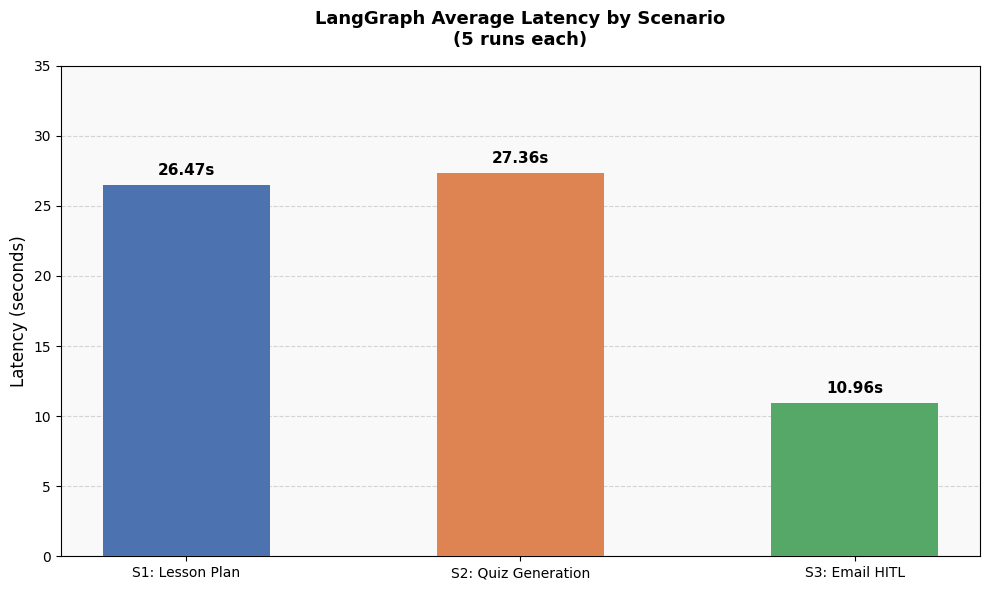

Chart saved: langgraph_latency_chart.png


In [26]:
import matplotlib.pyplot as plt

scenarios     = ["S1: Lesson Plan", "S2: Quiz Generation", "S3: Email HITL"]
avg_latencies = summary["avg_latency"].values.tolist()
colors        = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(scenarios, avg_latencies, color=colors, width=0.5, zorder=3)

# Value labels on top of each bar
for bar, val in zip(bars, avg_latencies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.2f}s",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("LangGraph Average Latency by Scenario\n(5 runs each)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Latency (seconds)", fontsize=12)
ax.set_ylim(0, 35)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.set_facecolor("#f9f9f9")

plt.tight_layout()
plt.savefig("langgraph_latency_chart.png", dpi=150)
plt.show()
print("Chart saved: langgraph_latency_chart.png")